In [1]:
%pip install numpy seaborn pandas matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)

   ---------------------------------------- 0/3 [contourpy]
   ---------------------------------------- 0/3 [contourpy]
   ---------------------------------------- 0/3 [contourpy]
   ---------------------------------------- 0/3 [contourpy]
   ---------------------------------------- 0/3 [contourpy]
   ---------------------------------------- 0/3 [contourpy]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [matplotlib]
   ------------- -------------------------- 1/3 [matplot


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import calendar

In [ ]:
df = pd.read_csv("births.csv")
# print(df.head(),"\n")
# print(df.shape)
# print(f"Maximum number of Births in a month {max(df.births)}") #Need to fix per month Records
# print(f"Minimum number of Births in a month {min(df.births)}")
# print(f"Minimum Day in a month {min(df.day)}") #Correct
print(f"Maximum Day in a month {max(df.day)}") #wrong
print(df.gender.unique()) #Correct 
print(df.month.unique())

print(df.info())
print(f"\nList of Not Assigned in DataFrame:\n{df.isna().sum()}")


(15547, 5)
Maximum Day in a month 99.0
<StringArray>
['F', 'M']
Length: 2, dtype: str
[ 1  2  3  4  5  6  7  8  9 10 11 12]
<class 'pandas.DataFrame'>
RangeIndex: 15547 entries, 0 to 15546
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    15547 non-null  int64  
 1   month   15547 non-null  int64  
 2   day     15067 non-null  float64
 3   gender  15547 non-null  str    
 4   births  15547 non-null  int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 607.4 KB
None

List of Not Assigned in DataFrame:
year        0
month       0
day       480
gender      0
births      0
dtype: int64


In [41]:
# df["month"].value_counts().sort_index()
daily = df[df["day"].notna()].copy()
daily["day"] = daily["day"].astype(int)  #float to int 

daily["max_day"] = daily.apply(
    lambda r: calendar.monthrange(int(r["year"]), int(r["month"]))[1], axis=1)


daily["status"] = "valid" #setting status column as valid and removing later on if value is invalid
daily.loc[daily["day"] == 99, "status"] = "sentinel_99"

# A day that is bigger than the month's real max day is impossible (e.g. Feb 30)
daily.loc[(daily["day"] != 99) & (daily["day"] > daily["max_day"]), "status"] = "impossible"

# A day below 1 is also impossible (there is no day 0 or negative day)
daily.loc[daily["day"] < 1, "status"] = "impossible"

# .value_counts() now shows how many rows are valid / sentinel / impossible
print(daily["status"].value_counts())

# Split the rows into three groups so we can handle each one differently
sentinel   = daily[daily["status"] == "sentinel_99"]
impossible = daily[daily["status"] == "impossible"]
valid      = daily[daily["status"] == "valid"]

# Show a few example impossible dates (these are data errors)
print("Example impossible dates (these are wrong and must be dropped):")
print(impossible[["year", "month", "day", "gender", "births"]].head(10))

# Show the leap-year Feb 29 rows (these are REAL and must be kept)
feb29 = valid[(valid["month"] == 2) & (valid["day"] == 29)]
print("Leap-year Feb 29 rows KEPT as valid:", len(feb29))
print(feb29[["year", "month", "day", "gender", "births"]].to_string(index=False))


status
valid          14610
sentinel_99      350
impossible       107
Name: count, dtype: int64
Example impossible dates (these are wrong and must be dropped):
     year  month  day gender  births
120  1969      2   29      F      50
121  1969      2   29      M      16
122  1969      2   30      F      24
123  1969      2   30      M      28
124  1969      2   31      F      24
125  1969      2   31      M      20
252  1969      4   31      F      28
253  1969      4   31      M      24
380  1969      6   31      F      20
381  1969      6   31      M      40
Leap-year Feb 29 rows KEPT as valid: 10
 year  month  day gender  births
 1972      2   29      F    4663
 1972      2   29      M    4919
 1976      2   29      F    3681
 1976      2   29      M    3878
 1980      2   29      F    4646
 1980      2   29      M    4969
 1984      2   29      F    4773
 1984      2   29      M    4907
 1988      2   29      F    4859
 1988      2   29      M    4939


In [48]:
# ---- STEP 4 : clean ----

# impossible.index = the row positions of the impossible dates 
# df.index.isin(...) = "is this row position in that list?" -> True/False
# ~ = "NOT" -> keep everything that is NOT an impossible date
before = len(df)
df = df[~df.index.isin(impossible.index)]
print("Impossible-date rows dropped:", before - len(df))
#same as impossible
before = len(df)
df = df[~df.index.isin(sentinel.index)]
print("Sentinel (day=99) rows dropped:", before - len(df))

# Make sure births are numbers
df["births"] = pd.to_numeric(df["births"], errors="coerce")

# More Readability for Gender
df["gender"] = df["gender"].str.strip().str.upper()

# Remove exact duplicate rows
df = df.drop_duplicates()
print("Rows left after cleaning:", len(df))


Impossible-date rows dropped: 107
Sentinel (day=99) rows dropped: 350
Rows left after cleaning: 15090


In [51]:
valid_rows = df[df["day"].notna()].copy() # Collecting so that we can sum for each month
monthly = df[df["day"].isna()].copy() #Collected as monthly

# groupby(["year","month","gender"]) = "group rows that share year+month+gender"
# This turns daily rows into monthly rows total because data is of 40 years
daily_monthly = valid_rows.groupby(["year", "month", "gender"], as_index=False)["births"].sum()

# Now combine the daily-years (now monthly) with the already-monthly years
clean = pd.concat([daily_monthly, monthly], ignore_index=True)

# Sort the table neatly by year, then month, then gender
clean = clean.sort_values(["year", "month", "gender"]).reset_index(drop=True)

# 40 years x 12 months x 2 genders = 960 rows. Every row now means the same thing!
clean.to_csv("births_cleaned_withmonthsOnly.csv", index=False)
print("Clean table shape:", clean.shape)
print(clean.head(8))


Clean table shape: (960, 5)
   year  month gender  births  day
0  1969      1      F  143704  NaN
1  1969      1      M  150172  NaN
2  1969      2      F  132218  NaN
3  1969      2      M  138316  NaN
4  1969      3      F  144020  NaN
5  1969      3      M  152416  NaN
6  1969      4      F  137182  NaN
7  1969      4      M  145288  NaN


In [58]:
clean["month"].value_counts().sort_index()

month
1     80
2     80
3     80
4     80
5     80
6     80
7     80
8     80
9     80
10    80
11    80
12    80
Name: count, dtype: int64

In [60]:
# Total births in Total
print("Total births 1969-2008:", int(clean["births"].sum()))

# Which month has the most births on average? (seasonality)
season = clean.groupby("month", as_index=False)["births"].mean()
print("Peak month (avg):", int(season.loc[season["births"].idxmax(), "month"]))

# Yearly totals per gender (for the scatter chart later)
yearly = clean.groupby(["year", "gender"], as_index=False)["births"].sum()
piv_y  = yearly.pivot(index="year", columns="gender", values="births").reset_index()
print("Correlation M vs F:", round(piv_y["M"].corr(piv_y["F"]), 3))


Total births 1969-2008: 151766945
Peak month (avg): 8
Correlation M vs F: 1.0


In [70]:
print(f"Maximum number of Births in a month {max(clean.births)}") 
print(f"Minimum number of Births in a month {min(clean.births)}")

print(clean.gender.unique()) 
print(clean.month.unique())

print(clean.info())
print(f"\nList of Not Assigned in DataFrame:\n{clean.isna().sum()}")


Maximum number of Births in a month 199622
Minimum number of Births in a month 115851
<StringArray>
['F', 'M']
Length: 2, dtype: str
[ 1  2  3  4  5  6  7  8  9 10 11 12]
<class 'pandas.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    960 non-null    int64  
 1   month   960 non-null    int64  
 2   gender  960 non-null    str    
 3   births  960 non-null    int64  
 4   day     0 non-null      float64
dtypes: float64(1), int64(3), str(1)
memory usage: 37.6 KB
None

List of Not Assigned in DataFrame:
year        0
month       0
gender      0
births      0
day       960
dtype: int64


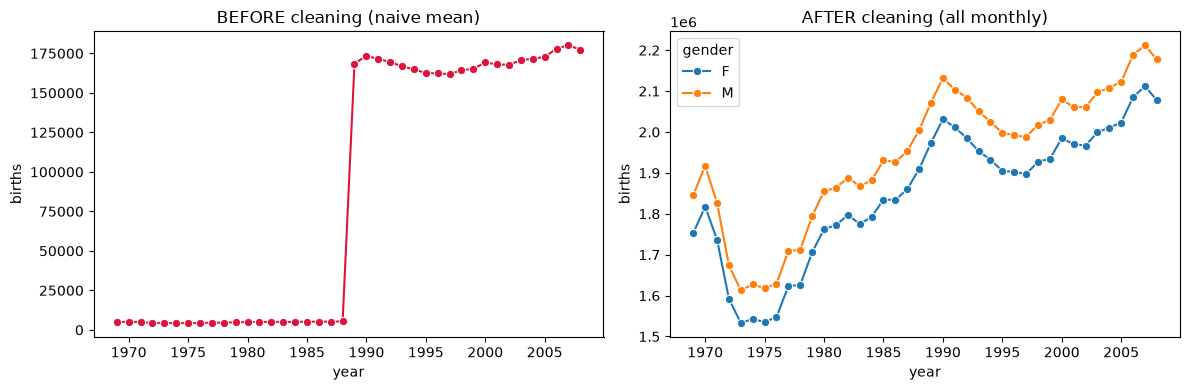

In [72]:
# ---- CHART 0 : before vs after ----

# The WRONG way: group by year and take the mean of whatever rows exist.
# Years 1969-88 have daily rows (~4,700) so the mean is small.
# Years 1989-08 have monthly rows (~170,000) so the mean is huge.
# -> a fake cliff in the middle of the chart!
naive = df.groupby("year")["births"].mean().reset_index()

# Make a figure with 1 row and 2 side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: the naive (wrong) yearly mean
sns.lineplot(data=naive, x="year", y="births", color="crimson", marker="o", ax=axes[0])
axes[0].set_title("BEFORE cleaning (naive mean)")

# Right plot: the cleaned yearly totals
sns.lineplot(data=yearly, x="year", y="births", hue="gender", marker="o", ax=axes[1])
axes[1].set_title("AFTER cleaning (all monthly)")

# make sure nothing overlaps, then show the figure
plt.tight_layout()
plt.show()


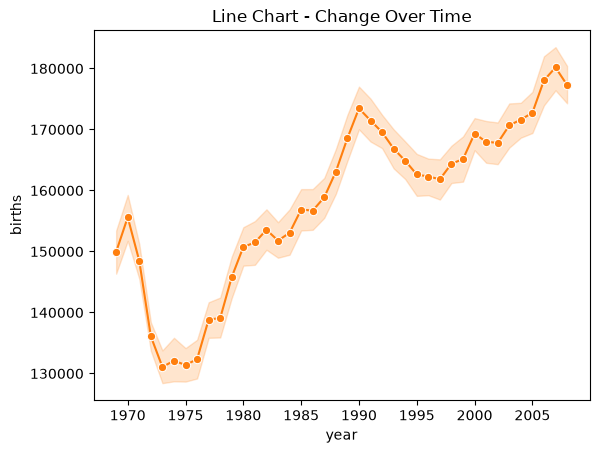

In [65]:
sns.lineplot(data=clean, x='year', y='births', marker='o', color='tab:orange')
plt.title("Line Chart - Change Over Time")
plt.show()

In [ ]:
sns.lineplot(data=df, x='year', y='births', marker='o', color='tab:orange')
plt.title("Line Chart - Change Over Time")
plt.show()